## Import and Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os

# Create directories if they don't exist
for folder in ['../data/raw', '../data/processed', '../models']:
    os.makedirs(folder, exist_ok=True)

## Downloads and Load Data

In [2]:
import pandas as pd
import urllib.request
import zipfile
import os

# 1. Define paths based on your project structure
# (Assuming this is running from inside the /notebooks folder)
zip_url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "../data/raw/sms_spam.zip"
extract_path = "../data/raw/"
final_csv_path = "../data/raw/spam.tsv"

# 2. Download the official zip file from UCI
if not os.path.exists(final_csv_path):
    print("Downloading dataset from UCI Machine Learning Repository...")
    urllib.request.urlretrieve(zip_url, zip_path)
    
    # 3. Extract the zip file
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        
    # 4. The official file is named 'SMSSpamCollection' (no extension). 
    # We rename it to 'spam.tsv' to match our pipeline.
    os.rename(os.path.join(extract_path, "SMSSpamCollection"), final_csv_path)
    
    # Clean up the zip file and readme to keep the raw folder clean
    os.remove(zip_path)
    os.remove(os.path.join(extract_path, "readme"))
    print("Download and extraction complete!")

# 5. Load the dataset into pandas
# The UCI dataset is tab-separated without a header
df = pd.read_csv(final_csv_path, sep='\t', header=None, names=['label', 'message'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1}) # Binarize labels

print(f"Dataset loaded successfully with {len(df)} records.")
print(df.head())

Dataset loaded successfully with 5572 records.
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


## EDA

label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


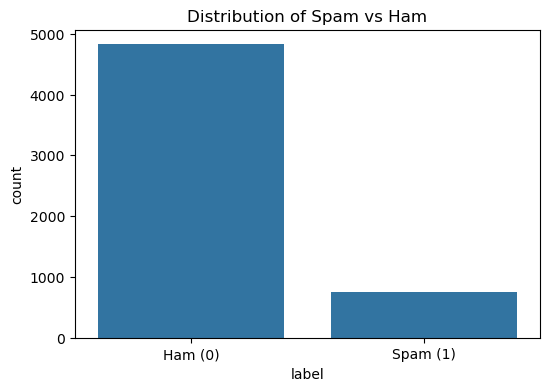

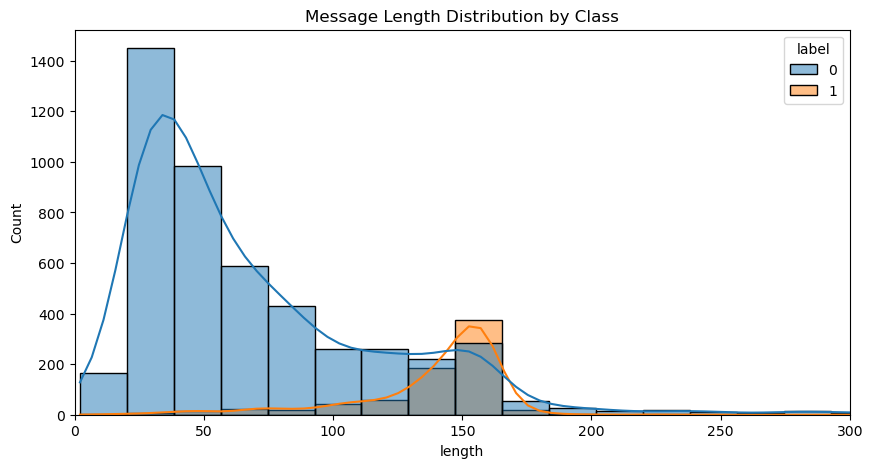

In [3]:
# Class distribution
print(df['label'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham')
plt.xticks([0,1], ['Ham (0)', 'Spam (1)'])
plt.show()

# Message length analysis
df['length'] = df['message'].apply(len)
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution by Class')
plt.xlim(0, 300)
plt.show()